<a href="https://colab.research.google.com/github/Josmanr3/TFG_Psoriasis/blob/main/EfficientNetB1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
Clasificación de Imágenes de Psoriasis usando el modelo EfficientNet
"""

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB1
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import xml.etree.ElementTree as ET
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input


# Configuración global
IMG_SIZE = (240, 240)
BATCH_SIZE = 32
LEARNING_RATE = 1e-4 #valores entre 1e-4 y 1e-5
EPOCHS = 50

# Descargar el dataset desde Roboflow (si no lo has hecho ya)
def download_dataset():
    try:
        !pip install roboflow
        from roboflow import Roboflow
        rf = Roboflow(api_key="ptzxcH0XI4loWLI9VAAb")
        project = rf.workspace("my-first-model-3qqjo").project("psoriasis-rtubr-ioewn")
        version = project.version(1)
        dataset = version.download("voc")  # Descargar en formato VOC
        return dataset.location
    except Exception as e:
        print(f"Error al descargar el dataset: {e}")
        # Si ya tienes el dataset descargado, especifica su ubicación
        return "/content/Psoriasis-1"

# Verificar y mostrar algunas imágenes
def verify_images(dataset_path):
    train_dir = os.path.join(dataset_path, "train")

    if not os.path.exists(train_dir):
        print(f"El directorio {train_dir} no existe.")
        return

    files = os.listdir(train_dir)
    image_files = [f for f in files if f.endswith(('.jpg', '.png', '.jpeg'))]

    if not image_files:
        print("No se encontraron imágenes en el directorio.")
        return

    # Mostrar algunas imágenes
    plt.figure(figsize=(15, 10))
    num_images = min(9, len(image_files))

    for i in range(num_images):
        img_path = os.path.join(train_dir, image_files[i])
        try:
            img = cv2.imread(img_path)
            if img is None:
                print(f"No se pudo cargar la imagen: {img_path}")
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(img)
            plt.title(f"Tamaño: {img.shape[0]} x {img.shape[1]}")
            plt.axis('off')
        except Exception as e:
            print(f"Error al procesar {img_path}: {e}")

    plt.tight_layout()
    plt.show()

    print(f"Se encontraron {len(image_files)} imágenes en {train_dir}")
    return True

# Cargar datos
def cargar_datos(dataset_path, split):
    ruta = os.path.join(dataset_path, split)
    if not os.path.exists(ruta):
        print(f"El directorio {ruta} no existe.")
        return np.array([]), np.array([])

    imagenes = []
    etiquetas = []
    problemas = 0

    # Primero, recopilar todas las etiquetas posibles
    xml_files = [f for f in os.listdir(ruta) if f.endswith('.xml')]

    for archivo in xml_files:
        xml_path = os.path.join(ruta, archivo)
        try:
            tree = ET.parse(xml_path)
            root = tree.getroot()

            # Obtener el nombre del archivo de imagen asociado
            nombre_imagen = root.find("filename").text
            imagen_path = os.path.join(ruta, nombre_imagen)

            if not os.path.exists(imagen_path):
                print(f"La imagen {imagen_path} no existe.")
                problemas += 1
                continue

            # Cargar y procesar la imagen
            imagen = cv2.imread(imagen_path)
            if imagen is None:
                print(f"No se pudo cargar la imagen: {imagen_path}")
                problemas += 1
                continue

            imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)  # Convertir a RGB
            imagen = cv2.resize(imagen, IMG_SIZE)  # Redimensionar
            imagenes.append(imagen)

            # Obtener la etiqueta (usamos la primera etiqueta por imagen para clasificación)
            # En un dataset de detección de objetos reales, podría haber múltiples objetos
            try:
                objeto = root.find("object")
                if objeto is not None:
                    etiqueta = objeto.find("name").text
                    etiquetas.append(etiqueta)
                else:
                    print(f"No se encontró ningún objeto en {xml_path}")
                    problemas += 1
            except Exception as e:
                print(f"Error al procesar etiquetas en {xml_path}: {e}")
                problemas += 1
        except Exception as e:
            print(f"Error al procesar {xml_path}: {e}")
            problemas += 1

    print(f"Problemas encontrados: {problemas} de {len(xml_files)} archivos XML")

    if not imagenes:
        print(f"No se pudieron cargar imágenes desde {ruta}")
        return np.array([]), np.array([])

    return np.array(imagenes), np.array(etiquetas)

In [ ]:
def crear_modelo(num_classes):
    # Modelo base
    base_model = EfficientNetB1(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
    )

    # Fine-tuning: descongelar algunas capas superiores para un mejor ajuste
    # Congelar las primeras capas y descongelar las últimas
    for layer in base_model.layers[:-20]:  # Mantener congeladas las primeras capas
        layer.trainable = False

    for layer in base_model.layers[-20:]:  # Descongelar las últimas 20 capas
        layer.trainable = True

    # Construir el modelo completo
    inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

    # MEJORA: Utilizamos el preprocess_input de EfficientNet en lugar de rescaling manual
    x = preprocess_input(inputs)

    # Extracto de características con el modelo base
    x = base_model(x, training=False)

    # Cabeza de clasificación
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.6)(x)
    x = layers.Dense(320, activation='relu')(x)
    #x = layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.6)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)

   # Compilación
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )

    # Muestra las capas del modelo
    model.summary()

    return model

In [ ]:
# Entrenar el modelo con mejor seguimiento y callbacks
def entrenar_modelo(model, X_train, y_train_cat, X_valid, y_valid_cat, class_weight_dict=None):
    # Callbacks
    checkpoint_cb = ModelCheckpoint(
        'EfficientNetB1_best.keras',
        save_best_only=True,
        monitor='val_accuracy',
        mode='max',
        verbose=1
    )
    # Early stopping
    earlystop_cb = EarlyStopping(
        monitor='val_loss',
        patience=6,
        restore_best_weights=True,
        verbose=1
    )

    # Reducción de learning rate cuando la mejora se estanca
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )

    # Data augmentation en tiempo real
    data_gen = ImageDataGenerator(
        rotation_range=20,
        width_shift_range=0.15,
        height_shift_range=0.15,
        shear_range=0.15,
        zoom_range=0.15,
        horizontal_flip=True,
        fill_mode='nearest',
        preprocessing_function=preprocess_input  # MEJORA: Usar el preprocesamiento específico de EfficientNet
    )

    # Preprocesamiento para validación
    valid_data_gen = ImageDataGenerator(
        preprocessing_function=preprocess_input  # MEJORA: Procesamiento consistente
    )

    # Flujo de datos
    train_gen = data_gen.flow(
        X_train, y_train_cat,
        batch_size=BATCH_SIZE
    )

    valid_gen = valid_data_gen.flow(
        X_valid, y_valid_cat,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    # Entrenar el modelo
    history = model.fit(
        train_gen,
        validation_data=valid_gen,
        epochs=EPOCHS,
        callbacks=[checkpoint_cb, earlystop_cb, reduce_lr],
        class_weight=class_weight_dict,
        verbose=1
    )

    return history, model

# Evaluar el modelo
def evaluar_modelo(model, X_test, y_test_cat, class_names):
    # MEJORA: Asegurar el mismo preprocesamiento para pruebas
    test_data_gen = ImageDataGenerator(
        preprocessing_function=preprocess_input
    )
    test_gen = test_data_gen.flow(
        X_test, y_test_cat,
        batch_size=BATCH_SIZE,
        shuffle=False
    )
    # Evaluación general
    print("\nEvaluación en el conjunto de prueba:")
    results = model.evaluate(X_test, y_test_cat, verbose=1)

    # Predicción para métricas detalladas
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_classes = np.argmax(y_test_cat, axis=1)

    # Mostrar algunas predicciones
    plt.figure(figsize=(15, 10))
    for i in range(min(9, len(X_test))):
        plt.subplot(3, 3, i + 1)
        plt.imshow(X_test[i])
        pred_class = class_names[y_pred_classes[i]]
        true_class = class_names[y_true_classes[i]]
        title = f"Pred: {pred_class}\nTrue: {true_class}"
        plt.title(title, color=("green" if pred_class == true_class else "red"))
        plt.axis('off')

    plt.tight_layout()
    plt.show()

    # Importar las métricas
    from sklearn.metrics import classification_report, confusion_matrix
    import seaborn as sns

    # Reporte de clasificación
    print("\nReporte de clasificación:")
    report = classification_report(y_true_classes, y_pred_classes, target_names=class_names)
    print(report)

    # Matriz de confusión
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(y_true_classes, y_pred_classes)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.title('Matriz de Confusión')
    plt.show()

    return results

# Graficar el historial de entrenamiento
def graficar_historial(history):
    plt.figure(figsize=(12, 5))

    # Gráfico de pérdida
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Entrenamiento')
    plt.plot(history.history['val_loss'], label='Validación')
    plt.title('Pérdida')
    plt.xlabel('Época')
    plt.ylabel('Pérdida')
    plt.legend()

    # Gráfico de precisión
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Entrenamiento')
    plt.plot(history.history['val_accuracy'], label='Validación')
    plt.title('Precisión')
    plt.xlabel('Época')
    plt.ylabel('Precisión')
    plt.legend()

    plt.tight_layout()
    plt.show()


loading Roboflow workspace...
loading Roboflow project...
Usando dataset en: /content/Psoriasis-1


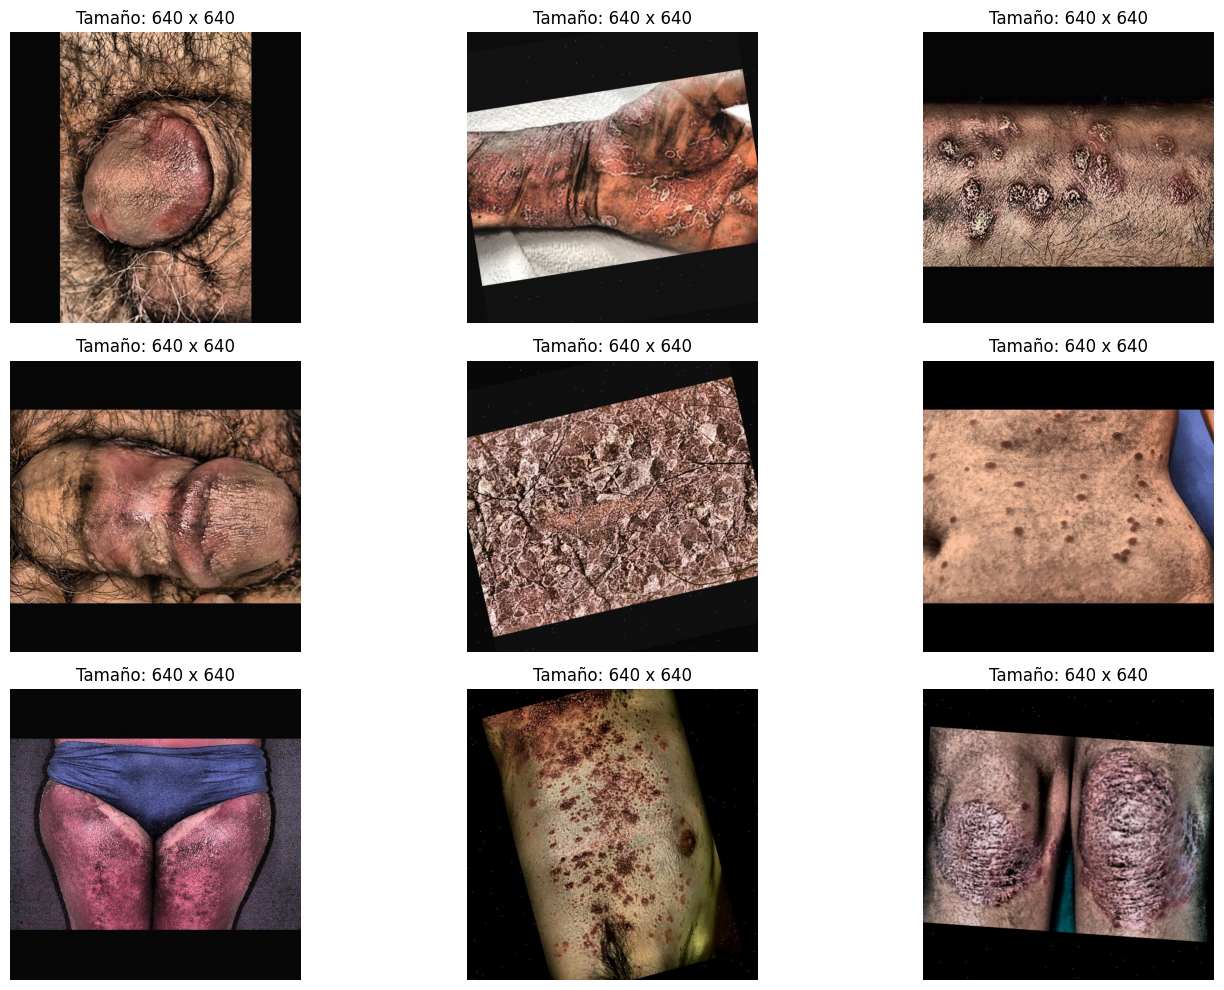

Se encontraron 939 imágenes en /content/Psoriasis-1/train

Cargando datos de entrenamiento...
Problemas encontrados: 0 de 939 archivos XML

Cargando datos de validación...
Problemas encontrados: 0 de 89 archivos XML

Cargando datos de prueba...
Problemas encontrados: 0 de 45 archivos XML

Datos cargados:
- Entrenamiento: (939, 240, 240, 3), (939,)
- Validación: (89, 240, 240, 3), (89,)
- Prueba: (45, 240, 240, 3), (45,)

Clases encontradas (5): ['Psoriasis Eritrodermica', 'Psoriasis Guttata', 'Psoriasis Inversa', 'Psoriasis Pustulosa', 'Psoriasis Vulgar']

Pesos de clase para balanceo:
- Clase Psoriasis Eritrodermica: 0.8575
- Clase Psoriasis Guttata: 1.8970
- Clase Psoriasis Inversa: 1.2520
- Clase Psoriasis Pustulosa: 0.9343
- Clase Psoriasis Vulgar: 0.6956

Creando modelo...


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 240, 240, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb1 (Functional)          │ (None, 8, 8, 1280)          │       6,575,239 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 320)                 │         409,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 320)                 │           1,280 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 320)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 5)                   │           1,605 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,993,164 (26.68 MB)

 Trainable params: 2,759,765 (10.53 MB)

 Non-trainable params: 4,233,399 (16.15 MB)


Iniciando entrenamiento...


Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.


Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.2169 - loss: 2.8734 - precision_1: 0.1912 - recall_1: 0.1441
Epoch 1: val_accuracy improved from -inf to 0.22472, saving model to EfficientNetB1_best.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 184s 5s/step - accuracy: 0.2176 - loss: 2.8670 - precision_1: 0.1925 - recall_1: 0.1451 - val_accuracy: 0.2247 - val_loss: 1.5214 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.3030 - loss: 2.3917 - precision_1: 0.3093 - recall_1: 0.2377
Epoch 2: val_accuracy improved from 0.22472 to 0.42697, saving model to EfficientNetB1_best.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 208s 5s/step - accuracy: 0.3034 - loss: 2.3875 - precision_1: 0.3102 - recall_1: 0.2384 - val_accuracy: 0.4270 - val_loss: 1.3333 - val_precision_1: 0.7273 - val_recall_1: 0.0899 - learning_rate: 1.0000e-04
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.3949 - loss: 1.8417 

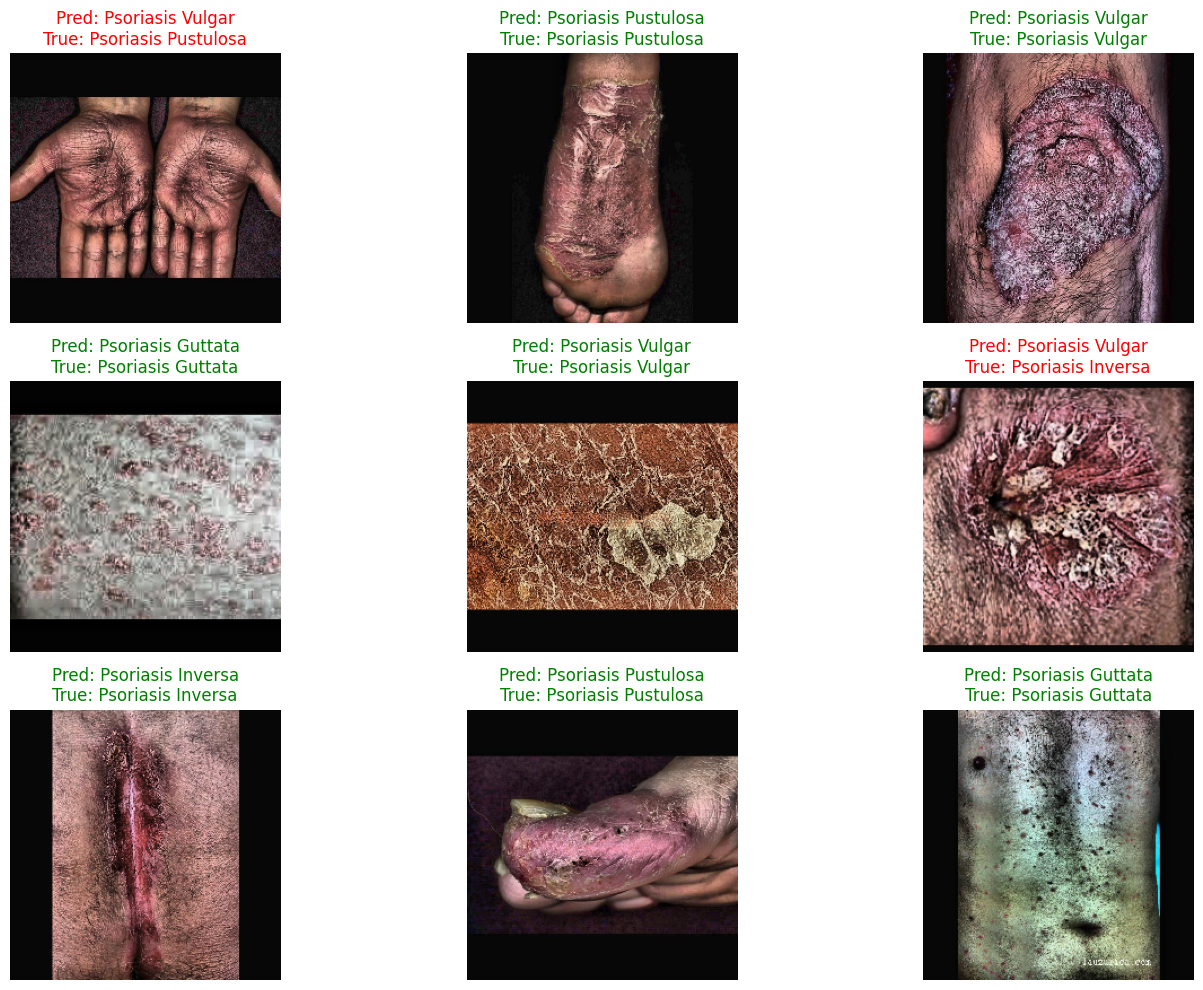


Reporte de clasificación:
                         precision    recall  f1-score   support

Psoriasis Eritrodermica       0.75      0.60      0.67         5
      Psoriasis Guttata       1.00      1.00      1.00         5
      Psoriasis Inversa       0.50      0.60      0.55         5
    Psoriasis Pustulosa       0.57      0.40      0.47        10
       Psoriasis Vulgar       0.70      0.80      0.74        20

               accuracy                           0.69        45
              macro avg       0.70      0.68      0.69        45
           weighted avg       0.69      0.69      0.68        45



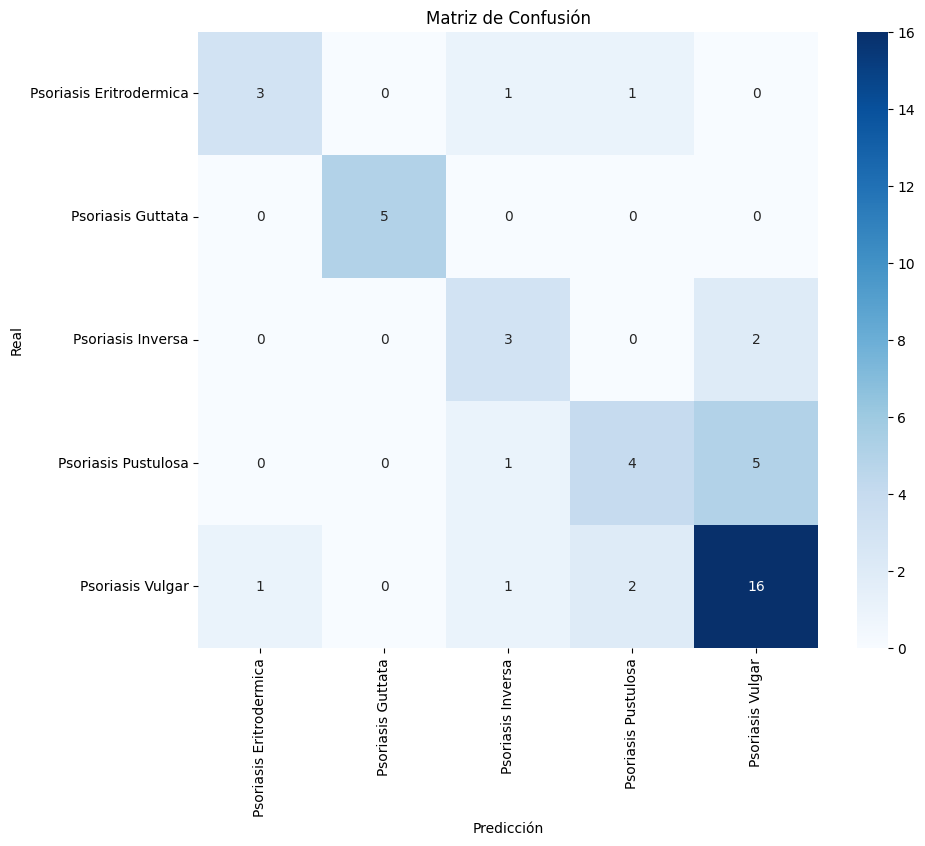

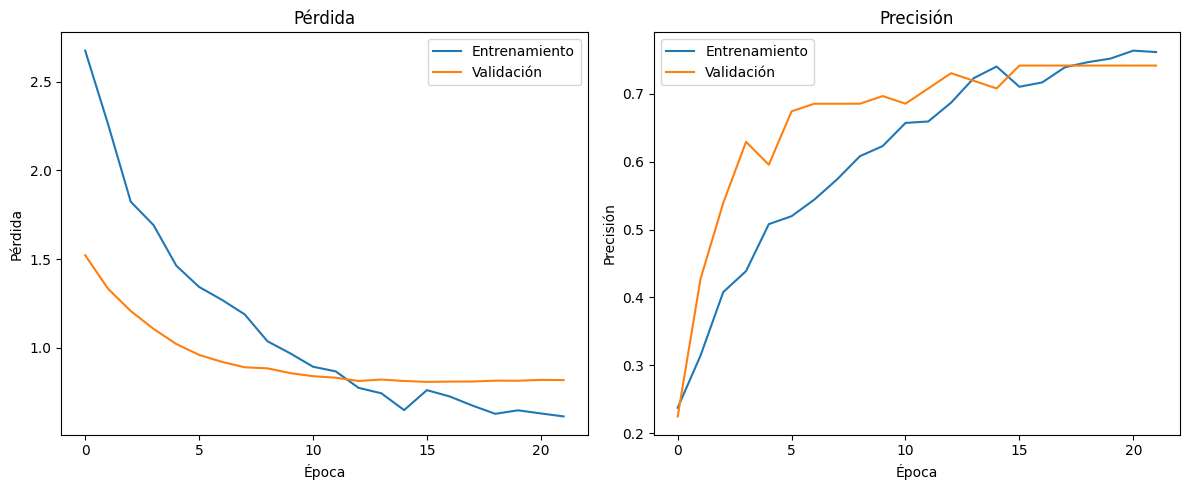


Modelo guardado como 'EfficientNetB1_final.h5'


In [ ]:
# Función principal
def main():
    # 1. Descargar o usar dataset existente
    dataset_path = download_dataset()
    print(f"Usando dataset en: {dataset_path}")

    # 2. Verificar imágenes
    if not verify_images(dataset_path):
        print("Problemas al verificar las imágenes. Revisa los directorios y formatos.")
        return

    # 3. Cargar y procesar datos
    print("\nCargando datos de entrenamiento...")
    X_train, y_train = cargar_datos(dataset_path, "train")

    print("\nCargando datos de validación...")
    X_valid, y_valid = cargar_datos(dataset_path, "valid")

    print("\nCargando datos de prueba...")
    X_test, y_test = cargar_datos(dataset_path, "test")

    # Verificar que se hayan cargado datos
    if len(X_train) == 0 or len(X_valid) == 0 or len(X_test) == 0:
        print("Error: No se pudieron cargar los datos correctamente.")
        return

    print(f"\nDatos cargados:\n- Entrenamiento: {X_train.shape}, {y_train.shape}")
    print(f"- Validación: {X_valid.shape}, {y_valid.shape}")
    print(f"- Prueba: {X_test.shape}, {y_test.shape}")

    # 4. Codificar etiquetas
    encoder = LabelEncoder()

    # Asegurarse de que el encoder vea todas las clases posibles
    all_labels = np.concatenate([y_train, y_valid, y_test])
    encoder.fit(all_labels)

    class_names = list(encoder.classes_)
    num_classes = len(class_names)

    print(f"\nClases encontradas ({num_classes}): {class_names}")

    # Codificar etiquetas
    y_train_encoded = encoder.transform(y_train)
    y_valid_encoded = encoder.transform(y_valid)
    y_test_encoded = encoder.transform(y_test)

    # One-hot encoding
    y_train_cat = to_categorical(y_train_encoded, num_classes=num_classes)
    y_valid_cat = to_categorical(y_valid_encoded, num_classes=num_classes)
    y_test_cat = to_categorical(y_test_encoded, num_classes=num_classes)

    # 5. Calcular pesos de clase para el desbalanceo
    class_weights = compute_class_weight(
        'balanced',
        classes=np.unique(y_train_encoded),
        y=y_train_encoded
    )
    class_weight_dict = dict(enumerate(class_weights))

    print("\nPesos de clase para balanceo:")
    for i, weight in enumerate(class_weights):
        print(f"- Clase {class_names[i]}: {weight:.4f}")

    # 6. Crear y compilar el modelo
    print("\nCreando modelo...")
    model = crear_modelo(num_classes)

    # 7. Entrenar el modelo
    print("\nIniciando entrenamiento...")
    history, trained_model = entrenar_modelo(
        model, X_train, y_train_cat, X_valid, y_valid_cat, class_weight_dict
    )

    # 8. Evaluar el modelo
    print("\nEvaluando modelo...")
    results = evaluar_modelo(trained_model, X_test, y_test_cat, class_names)

    # 9. Visualizar el historial de entrenamiento
    graficar_historial(history)

    # 10. Guardar el modelo
    trained_model.save('EfficientNetB1_final.h5')
    print("\nModelo guardado como 'EfficientNetB1_final.h5'")

    return trained_model, history, results

if __name__ == "__main__":
    main()